# Исследовательский анализ данных

Ноутбук для первичного исследования данных перед построением GLM моделей.

**Структура:**
1. Загрузка данных и определение схемы
2. Определение подмножества для исследования
3. Описательные статистики
4. Распределения признаков и таргетов
5. Подбор параметров распределений для таргетов
6. Корреляционный анализ с проверкой численной устойчивости
7. Feature importance через дерево решений
8. Многомерные визуализации

## 1. Импорт библиотек

In [1]:
import os
import sys
import pandas as pd
import numpy as np
from scipy.stats import expon, gamma, poisson, norm, gaussian_kde
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.pipeline import Pipeline
from ipyfilechooser import FileChooser
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Путь к deps/repo_glm для axiolyze (если пакет не установлен через pip install -e)
from pathlib import Path
_glm_path = Path('../../deps/repo_glm').resolve()
if str(_glm_path) not in sys.path:
    sys.path.insert(0, str(_glm_path))

# Legacy-скрипты: support, model_io, io_utils, glm_analysis, ui
_legacy_path = Path('../../deps/repo_glm/axiolyze/legacy').resolve()
if str(_legacy_path) not in sys.path:
    sys.path.insert(0, str(_legacy_path))

# Импорт из axiolyze
from axiolyze.core.schema import DataSchema
from axiolyze.notebooks.widgets import MultiTabSelector

# support, likelihood_utils, ui — из axiolyze/legacy/ (добавлено в sys.path выше)
# Примечание: likelihood_utils.py отсутствует в репозитории — требует отдельного файла
from support import (
    selection_rule_column, selection_preprocess, filter_dataframe,
    compute_correlation_matrices, plot_correlation_matrices,
    plot_correlation_and_determination, plot_multiple
)
from likelihood_utils import fit_3component_mixture
from ui import FilterFeatures, SimpleGui

# Функция загрузки из SQL с fallback на sqlalchemy
def read_df_from_sql(query, sql_server_name=None, db_name=None, **kwargs):
    """Загрузка из SQL: vsk_omtl или fallback на sqlalchemy."""
    try:
        from vsk_omtl import read_df_from_sql as custom_read_sql
        return custom_read_sql(
            query=query,
            sql_server_name=sql_server_name,
            db_name=db_name,
            **kwargs
        )
    except (ImportError, NameError):
        try:
            from sqlalchemy import create_engine
            if sql_server_name and db_name:
                connection_string = f"mssql+pyodbc://@{sql_server_name}/{db_name}?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"
            else:
                connection_string = kwargs.pop('connection_string', 'sqlite:///:memory:')
            engine = create_engine(connection_string)
            return pd.read_sql(query, con=engine, **kwargs)
        except Exception as e:
            raise ValueError(f"Не удалось загрузить данные из SQL: {e}")

## 2. Настройки

In [2]:
# Параметры для визуализации
num_for_draw = 1000  # Сколько данных взять для рисования статистик (используется в ячейке 17)
is_dataset_large = True  # Флаг для больших датасетов (используется в ячейке 17)
# dataset_name = 'research_dataset'  # Имя датасета для сохранения результатов (не используется, закомментировано)

## 3. Загрузка данных

**Цель:** Загрузить данные из файла (CSV/Feather) или SQL запроса.

**Что смотрим:** Структуру данных, типы колонок, наличие пропусков.

**Варианты загрузки:**
- Из файла (CSV/Feather)
- Из SQL запроса (с fallback на sqlalchemy)

In [3]:
# Выбор источника данных: файл или SQL
fc_data = FileChooser(
    path='.',
    filename='',
    filter_pattern=('*.csv', '*.feather'),
    title='ВАРИАНТ 1: Выберите файл данных для анализа (CSV или Feather)'
)
display(fc_data)

fc_sql = FileChooser(
    path='.',
    filename='',
    filter_pattern=('*.sql',),
    title='ВАРИАНТ 2: Выберите файл с SQL запросом'
)
display(fc_sql)

FileChooser(path='C:\axiolyzeProject\visualaxiolyze\data\research_analysis_clean_improved', filename='', title…

FileChooser(path='C:\axiolyzeProject\visualaxiolyze\data\research_analysis_clean_improved', filename='', title…

In [4]:
# Загрузка данных из файла
if fc_data.selected:
    file_path = fc_data.selected
    if file_path.endswith('.csv'):
        df_raw = pd.read_csv(file_path)
    elif file_path.endswith('.feather'):
        df_raw = pd.read_feather(file_path)
    
    print(f"✅ Загружено из файла: {file_path}")
    print(f"Загружено строк: {df_raw.shape[0]}, колонок: {df_raw.shape[1]}")
    
# Загрузка данных из SQL
elif fc_sql.selected:
    # Читаем SQL запрос из файла
    with open(fc_sql.selected, 'r', encoding='utf-8') as f:
        query = f.read()
    
    # Параметры подключения к БД (настройте под вашу БД)
    sql_server_name = None  # Например: 'actuar4'
    db_name = None  # Например: 'Casco_2025_08'
    
    # Если нужна кастомная конфигурация БД, раскомментируйте:
    # import os
    # lib_name = 'vsk_omtl'
    # tag = 'master'
    # os.system('git archive --format=tar --remote=git://actuar-ml1/vsk_init.git master _util_lib_init.py | tar x --overwrite')
    # os.system('git archive --format=tar --remote=git://actuar-ml1/vsk_init.git master _configs.yaml | tar x --overwrite')
    # os.system(f'git archive --format=tar --remote=git://actuar-ml1/{lib_name}.git --prefix={lib_name}/ {tag} | tar x --overwrite')
    # import _util_lib_init
    # from vsk_omtl import *
    # local_config = _util_lib_init.get_config_from_file('_configs.yaml')
    # local_config_db = local_config.db.toDict()
    # df_raw = read_df_from_sql(query=query, sql_server_name=sql_server_name, db_name=db_name, **local_config_db)
    
    # Загрузка через функцию с fallback
    df_raw = read_df_from_sql(
        query=query,
        sql_server_name=sql_server_name,
        db_name=db_name,
        n_jobs=1,
        debug_sql=False
    )
    
    print(f"✅ Загружено из SQL: {fc_sql.selected}")
    print(f"Загружено строк: {df_raw.shape[0]}, колонок: {df_raw.shape[1]}")
    
else:
    print("⚠️ Не выбран источник данных. Выберите файл или SQL запрос выше.")
    df_raw = None

# Показываем информацию о данных
if df_raw is not None:
    print(f"\nПервые строки:")
    display(df_raw.head(2))
    print(f"\nТипы данных:")
    print(df_raw.dtypes)
    print(f"\nПропуски:")
    print(df_raw.isnull().sum())

✅ Загружено из файла: C:\axiolyzeProject\visualaxiolyze\data\unbalanced_dataset_train.csv
Загружено строк: 10000, колонок: 6

Первые строки:


,Unnamed: 0,Марка,YearMonth,Страховая сумма,Количество дней от события до урегулирования,Оценка убытка
0,0,Жигули,202404,374512.239140,43.0,98674
1,1,Лада Самара,202501,624627.110258,13.0,160331



Типы данных:
Unnamed: 0                                        int64
Марка                                            object
YearMonth                                         int64
Страховая сумма                                 float64
Количество дней от события до урегулирования    float64
Оценка убытка                                     int64
dtype: object

Пропуски:
Unnamed: 0                                        0
Марка                                             0
YearMonth                                         0
Страховая сумма                                   0
Количество дней от события до урегулирования    100
Оценка убытка                                     0
dtype: int64


## 4. Определение схемы данных

**Цель:** Определить структуру данных - какие колонки являются таргетами, индексами, экспозицией, признаками.

**Варианты:**
- Загрузить сохраненную схему (если есть)
- Создать новую схему через виджет


In [5]:
# Попытка загрузить сохраненную схему данных
fc_schema = FileChooser(
    path='.',
    filename='',
    filter_pattern=('*.yml', '*.yaml'),
    title='Попытка загрузить сохраненную схему данных (опционально)'
)
display(fc_schema)

FileChooser(path='C:\axiolyzeProject\visualaxiolyze\data\research_analysis_clean_improved', filename='', title…

In [6]:
# Загрузка схемы из файла (если выбрана)
schema = None
if fc_schema.selected and df_raw is not None:
    try:
        schema = DataSchema.load(fc_schema.selected, df=df_raw)
        print("✅ Схема успешно загружена из файла")
        print(f"  Таргеты: {schema.target_columns}")
        print(f"  Индексы: {schema.index_columns}")
        print(f"  Экспозиция: {schema.exposure_column}")
        print(f"  Числовые признаки: {len(schema.numeric_columns)}")
        print(f"  Категориальные признаки: {len(schema.categorical_columns)}")
    except ValueError as e:
        print("⚠️ Схема не соответствует данным:")
        print(str(e))
        print("\n💡 Рекомендация: создайте новую схему, используя виджеты ниже.")
        print("   Схема будет автоматически определена на основе доступных колонок в датафрейме.")
        schema = None
    except FileNotFoundError:
        print("⚠️ Файл схемы не найден. Создайте новую схему ниже.")
        schema = None
else:
    print("💡 Схема не выбрана. Создайте новую схему ниже.")

✅ Схема успешно загружена из файла
  Таргеты: ['Оценка убытка']
  Индексы: ['Unnamed: 0']
  Экспозиция: Create new
  Числовые признаки: 2
  Категориальные признаки: 2


In [7]:
# Создание схемы данных через MultiTabSelector (если схема не загружена)
if schema is None and df_raw is not None:
    # Подготовка данных для виджета
    data = {key: {'value': str(value)} for key, value in df_raw.head(2).items()}
    
    # Определяем числовые и категориальные столбцы для удобства
    numerical_features = df_raw.select_dtypes(include=[np.number]).columns.tolist()
    categorical_features = df_raw.select_dtypes(include=['object', 'category']).columns.tolist()
    
    # Конфигурация вкладок для MultiTabSelector
    # Объединяем функциональность TechFeatures и ForceFeatures в один виджет
    tabs_config_schema = [
        {
            'name': 'target',
            'title': 'Targets',
            'columns': None,  # Все колонки доступны
            'create_new': False,
            'block_others': True,  # Блокирует выбор в других вкладках
            'max_selections': None  # Можно выбрать несколько таргетов
        },
        {
            'name': 'index',
            'title': 'Index',
            'columns': None,
            'create_new': False,
            'block_others': True,
            'max_selections': None
        },
        {
            'name': 'exposure',
            'title': 'Exposure',
            'columns': numerical_features,  # Только числовые для экспозиции
            'create_new': False,
            'block_others': True,
            'max_selections': 1  # Только одна экспозиция
        },
        {
            'name': 'force_cat',
            'title': 'Force Categorical',
            'columns': None,
            'create_new': False,
            'block_others': False,  # Не блокирует другие вкладки
            'max_selections': None
        },
        {
            'name': 'force_num',
            'title': 'Force Numeric',
            'columns': None,
            'create_new': False,
            'block_others': False,
            'max_selections': None
        },
        {
            'name': 'force_time',
            'title': 'Force Time',
            'columns': None,
            'create_new': False,
            'block_others': False,
            'max_selections': None
        },
        {
            'name': 'to_drop',
            'title': 'To Drop',
            'columns': None,
            'create_new': False,
            'block_others': False,
            'max_selections': None
        }
    ]
    
    schema_widget = MultiTabSelector(data, tabs_config_schema, show_summary=True)
    display(schema_widget)
else:
    print("✅ Схема уже загружена. Пропускаем создание виджета.")

✅ Схема уже загружена. Пропускаем создание виджета.


In [8]:
# Извлекаем настройки из виджета и создаем схему данных
if schema is None and df_raw is not None:
    # Сохраняем выбор из всех вкладок
    schema_widget._select_all(schema_widget._btn_select_all)
    
    # Извлекаем выбранные значения
    target_list = schema_widget.target.selected
    index_ = schema_widget.index.selected
    exposure_ = schema_widget.exposure.selected[0] if schema_widget.exposure.selected else None
    force_cat = schema_widget.force_cat.selected
    force_num = schema_widget.force_num.selected
    force_time = schema_widget.force_time.selected
    to_drop = schema_widget.to_drop.selected
    
    # Создаем схему данных через DataSchema
    # target может быть списком или одним значением
    schema = DataSchema.from_dataframe(
        df=df_raw,
        target=target_list,  # Список таргетов
        index=index_,
        exposure=exposure_,
        force_categorical=force_cat,
        force_numeric=force_num,
        trash_columns=to_drop,
        datetime_columns=force_time
    )
    
    # Вычисляем доступные числовые из данных только для информативности (для print)
    # Это показывает, сколько числовых признаков есть в исходных данных
    # schema.numeric_columns всегда заполнен (содержит все доступные числовые)
    features = [col for col in df_raw.columns if col not in index_ and col != exposure_]
    available_numeric_from_data = [col for col in df_raw[features].select_dtypes(include=[np.number]).columns
                                   if col not in (force_cat + force_time + to_drop)]
    
    print(f"\n✅ Схема данных создана:")
    print(f"  Таргеты: {schema.target_columns}")
    print(f"  Индексы: {schema.index_columns}")
    print(f"  Экспозиция: {schema.exposure_column}")
    print(f"  Числовые признаки (доступные в данных): {len(available_numeric_from_data)}")
    print(f"  Числовые признаки (в схеме): {len(schema.numeric_columns)}")
    print(f"  Категориальные признаки (доступные): {len(schema.available_categorical_columns)}")
    print(f"  Категориальные признаки (выбранные): {len(schema.categorical_columns)}")
else:
    print("✅ Схема уже определена (загружена из файла или создана ранее)")

✅ Схема уже определена (загружена из файла или создана ранее)


## 5. Определение подмножества для исследования

**Цель:** Выбрать подмножество данных для детального анализа (fine_schema).

**Что смотрим:** Какие признаки и строки включить в исследование, чтобы сфокусироваться на важных аспектах.

In [9]:
# Фильтрация по категориальным признакам (опционально)
categoricals = schema.available_categorical_columns
if len(categoricals) > 0:
    counts = selection_preprocess(df_raw[categoricals], sort_by='name', normalize=True, feature_type='categorical')
    filter_ui = FilterFeatures(counts)
    display(filter_ui)
else:
    filter_config = {}

In [10]:
# Применяем фильтрацию (если была выбрана)
if len(categoricals) > 0 and hasattr(filter_ui, 'selected'):
    df_filtered = filter_dataframe(df_raw, counts, filter_ui.selected)
else:
    df_filtered = df_raw.copy()

print(f"После фильтрации: {df_filtered.shape[0]} строк (было {df_raw.shape[0]})")

После фильтрации: 10000 строк (было 10000)


In [11]:
# Выбор подмножества признаков для анализа через MultiTabSelector
# Выбираем подмножества числовых, категориальных признаков и таргетов
if schema is not None and df_filtered is not None:
    # Подготовка данных для виджета
    data = {key: {'value': str(value)} for key, value in df_filtered.head(2).items()}
    
    # Конфигурация вкладок для выбора подмножества
    tabs_config_fine = [
        {
            'name': 'numeric',
            'title': 'Numeric Features',
            'columns': schema.numeric_columns,  # Только числовые из схемы
            'create_new': False,
            'block_others': False,
            'max_selections': None
        },
        {
            'name': 'categorical',
            'title': 'Categorical Features',
            'columns': schema.categorical_columns,  # Все доступные категориальные
            'create_new': False,
            'block_others': False,
            'max_selections': None
        },
        {
            'name': 'targets',
            'title': 'Targets',
            'columns': schema.target_columns,  # Таргеты из схемы
            'create_new': False,
            'block_others': False,
            'max_selections': None
        }
    ]
    
    fine_schema_widget = MultiTabSelector(data, tabs_config_fine, show_summary=True)
    display(fine_schema_widget)
else:
    print("⚠️ Схема не определена или данные не загружены")

MultiTabSelector(children=(Tab(children=(_TabContent(children=(BodyToggleButtonList(children=(CustomToggleButt…

In [12]:
# Создаем fine_schema с выбранными признаками
# Инициализируем переменные для глобального доступа
selected_numeric = []
selected_categorical = []
selected_targets = []

if schema is not None and df_filtered is not None:
    # Сохраняем выбор из всех вкладок
    fine_schema_widget._select_all(fine_schema_widget._btn_select_all)
    
    # Извлекаем выбранные значения
    selected_numeric = fine_schema_widget.numeric.selected
    selected_categorical = fine_schema_widget.categorical.selected
    selected_targets = fine_schema_widget.targets.selected if fine_schema_widget.targets.selected else schema.target_columns
    
    # Создаем fine_schema с выбранными подмножествами
    fine_schema = DataSchema(
        target_columns=selected_targets,  # Выбранные таргеты (или все из схемы)
        index_columns=schema.index_columns,
        exposure_column=schema.exposure_column,
        categorical_columns=selected_categorical,  # Выбранное подмножество категориальных
        numeric_columns=selected_numeric  # Выбранное подмножество числовых
    )
    
    print(f"✅ Fine schema создана:")
    print(f"  Таргеты: {fine_schema.target_columns} ({len(fine_schema.target_columns)})")
    print(f"  Числовые признаки: {len(selected_numeric)} из {len(schema.numeric_columns)}")
    print(f"  Категориальные признаки: {len(selected_categorical)} из {len(schema.available_categorical_columns)}")
    
    # Подготовка данных для анализа (включаем выбранные признаки и таргеты)
    selected_features = selected_numeric + selected_categorical
    df_to_draw = df_filtered[selected_features + selected_targets].dropna()
    
    if is_dataset_large:
        shape0 = min(num_for_draw, df_to_draw.shape[0])
        df_to_draw = df_to_draw.sample(shape0, random_state=42)
    
    print(f"\nДанные для анализа: {df_to_draw.shape[0]} строк, {df_to_draw.shape[1]} колонок")
else:
    print("⚠️ Схема не определена или данные не загружены")

✅ Fine schema создана:
  Таргеты: ['Оценка убытка'] (1)
  Числовые признаки: 1 из 2
  Категориальные признаки: 1 из 0

Данные для анализа: 1000 строк, 3 колонок


## 6. Описательные статистики

**Цель:** Получить общее представление о данных через базовые статистики.

**Что смотрим:** Средние, медианы, квантили, частоты категорий.

In [13]:
# Описательные статистики симметрично для числовых и категориальных
print("Описательные статистики для числовых признаков:")
if len(selected_numeric) > 0:
    display(df_to_draw[selected_numeric].describe())
else:
    print("  Нет числовых признаков")

print("\nЧастоты категориальных признаков:")
if len(selected_categorical) > 0:
    for col in selected_categorical[:5]:  # Показываем первые 5
        print(f"\n{col}:")
        print(df_to_draw[col].value_counts().head(10))
else:
    print("  Нет категориальных признаков")

Описательные статистики для числовых признаков:


,Страховая сумма
count,1.000000e+03
mean,1.830491e+06
std,2.033363e+06
min,1.682141e+05
25%,4.493479e+05
50%,9.344579e+05
75%,2.292376e+06
max,1.367778e+07



Частоты категориальных признаков:

Марка:
Марка
Киа              291
Жигули           200
Лада Самара      187
Lada             180
Мерседес-Бенц    134
Mercedes           8
Name: count, dtype: int64


In [14]:
# Выбор признака или таргета для визуализации распределения
# Используем fine_schema и виджет для выбора
all_for_distribution = fine_schema.numeric_columns + fine_schema.categorical_columns + fine_schema.target_columns

if len(all_for_distribution) > 0:
    column_selector_ui = SimpleGui({key: {'value': str(value)} for key, value in df_to_draw.head(2).items()
                                                              if key in all_for_distribution})
    display(column_selector_ui)
else:
    print("⚠️ Нет доступных столбцов для визуализации распределений")

SimpleGui(children=(HTML(value=''), BodyToggleButtonList(children=(CustomToggleButton(value=False, description…

Анализируем распределение: Страховая сумма


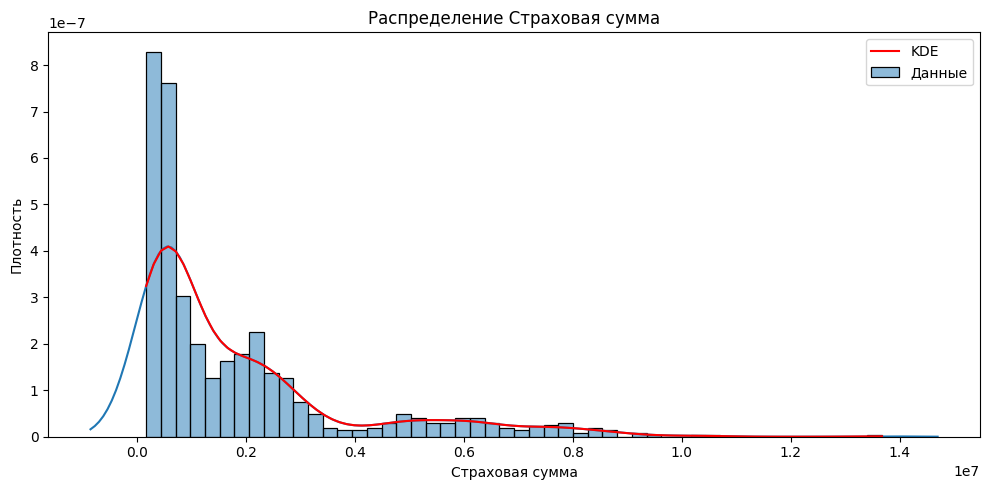

In [15]:
# Визуализация распределения выбранного столбца
# Получаем выбранный столбец из виджета
if 'column_selector_ui' in locals() and hasattr(column_selector_ui, 'selected') and column_selector_ui.selected:
    column = column_selector_ui.selected[0]
else:
    # Fallback: первый доступный
    column = (fine_schema.numeric_columns[0] if fine_schema.numeric_columns
              else (fine_schema.target_columns[0] if fine_schema.target_columns else None))
    if column is None:
        print("Нет доступных столбцов для анализа")
        column = None

if column and column in df_to_draw.columns:
    print(f"Анализируем распределение: {column}")
    column_data = df_to_draw[column]
    
    # Для числовых - гистограмма с KDE
    if column in fine_schema.numeric_columns or column in fine_schema.target_columns:
        kde = gaussian_kde(column_data.dropna())
        x = np.linspace(column_data.min(), column_data.max(), 100)
        
        _, ax = plt.subplots(figsize=(10, 5))
        sns.histplot(column_data, kde=True, kde_kws=dict(cut=2), ax=ax, stat='density', bins=50, label='Данные')
        sns.lineplot(x=x, y=kde(x), label='KDE', ax=ax, color='red')
        ax.set_title(f"Распределение {column}")
        ax.set_xlabel(column)
        ax.set_ylabel('Плотность')
        ax.legend()
        plt.tight_layout()
        plt.show()
    else:
        # Для категориальных - barplot
        _, ax = plt.subplots(figsize=(12, 5))
        value_counts = column_data.value_counts().head(20)
        sns.barplot(x=value_counts.index.astype(str), y=value_counts.values, ax=ax)
        ax.set_title(f"Распределение {column}")
        ax.set_xlabel(column)
        ax.set_ylabel('Частота')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
else:
    print("⚠️ Столбец не выбран или отсутствует в данных")

## 7. Распределения признаков и таргетов

**Цель:** Визуально оценить распределения признаков и таргетов для понимания их структуры.

**Что смотрим:** Форму распределений, наличие выбросов, модальность, асимметрию.

**Зачем:** Это помогает выбрать правильное семейство распределений для GLM и понять, нужны ли трансформации.

In [ ]:
# Выбор признака или таргета для визуализации распределения
# Используем fine_schema и виджет для выбора
all_for_distribution = fine_schema.numeric_columns + fine_schema.categorical_columns + fine_schema.target_columns

if len(all_for_distribution) > 0:
    column_selector_ui = SimpleGui({key: {'value': str(value)} for key, value in df_to_draw.head(2).items()
                                                              if key in all_for_distribution})
    display(column_selector_ui)
else:
    print("⚠️ Нет доступных столбцов для визуализации распределений")

SimpleGui(children=(HTML(value=''), BodyToggleButtonList(children=(CustomToggleButton(value=False, description…

Анализируем распределение: Страховая сумма


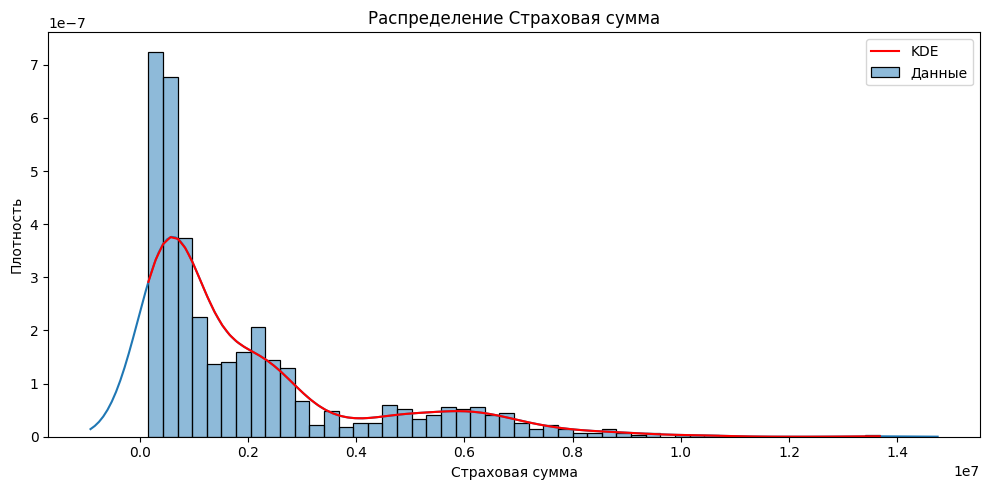

In [ ]:
# Визуализация распределения выбранного столбца
# Получаем выбранный столбец из виджета
if 'column_selector_ui' in locals() and hasattr(column_selector_ui, 'selected') and column_selector_ui.selected:
    column = column_selector_ui.selected[0]
else:
    # Fallback: первый доступный
    column = (fine_schema.numeric_columns[0] if fine_schema.numeric_columns
              else (fine_schema.target_columns[0] if fine_schema.target_columns else None))
    if column is None:
        print("Нет доступных столбцов для анализа")
        column = None

if column and column in df_to_draw.columns:
    print(f"Анализируем распределение: {column}")
    column_data = df_to_draw[column]
    
    # Для числовых - гистограмма с KDE
    if column in fine_schema.numeric_columns or column in fine_schema.target_columns:
        kde = gaussian_kde(column_data.dropna())
        x = np.linspace(column_data.min(), column_data.max(), 100)
        
        _, ax = plt.subplots(figsize=(10, 5))
        sns.histplot(column_data, kde=True, kde_kws=dict(cut=2), ax=ax, stat='density', bins=50, label='Данные')
        sns.lineplot(x=x, y=kde(x), label='KDE', ax=ax, color='red')
        ax.set_title(f"Распределение {column}")
        ax.set_xlabel(column)
        ax.set_ylabel('Плотность')
        ax.legend()
        plt.tight_layout()
        plt.show()
    else:
        # Для категориальных - barplot с улучшенным представлением
        _, ax = plt.subplots(figsize=(12, 5))
        value_counts = column_data.value_counts().head(20)
        # Преобразуем индексы в строки для корректного отображения
        sns.barplot(x=value_counts.index.astype(str), y=value_counts.values, ax=ax)
        ax.set_title(f"Распределение {column}")
        ax.set_xlabel(column)
        ax.set_ylabel('Частота')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
else:
    print("⚠️ Столбец не выбран или отсутствует в данных")

## 8. Подбор параметров распределений для таргетов

**Цель:** Количественно оценить параметры смеси распределений для таргетов.

**Что смотрим:** Веса компонент смеси (экспоненциальное, гамма, пуассон), параметры каждой компоненты.

**Зачем:** Это помогает выбрать правильное семейство распределения для GLM (Poisson, Gamma, Tweedie и т.д.).

**Связь с предыдущим разделом:** Сначала визуально оценили распределения, теперь количественно подбираем параметры.

In [27]:
# Выбор таргета или столбца для подбора параметров распределений
# Используем fine_schema и виджет для выбора
targets_and_numeric = fine_schema.target_columns + fine_schema.numeric_columns

if len(targets_and_numeric) > 0:
    target_selector_ui = SimpleGui({key: {'value': str(value)} for key, value in df_to_draw.head(2).items()
                                                             if key in targets_and_numeric})
    display(target_selector_ui)
else:
    print("⚠️ Нет доступных таргетов или числовых признаков для подбора параметров")

SimpleGui(children=(HTML(value=''), BodyToggleButtonList(children=(CustomToggleButton(value=False, description…

In [28]:
# Подбор параметров для выбранного таргета/столбца
# Получаем выбранный столбец из виджета
target_for_fitting = None
if 'target_selector_ui' in locals() and hasattr(target_selector_ui, 'selected') and target_selector_ui.selected:
    target_for_fitting = target_selector_ui.selected[0]
else:
    # Fallback: первый таргет
    target_for_fitting = (fine_schema.target_columns[0] if fine_schema.target_columns
                          else (fine_schema.numeric_columns[0] if fine_schema.numeric_columns else None))
    if target_for_fitting is None:
        print("Нет доступных столбцов для подбора параметров")
        target_for_fitting = None

if target_for_fitting and target_for_fitting in df_to_draw.columns:
    # Переименовываем переменную data в target_data для избежания конфликтов
    target_data = df_to_draw[target_for_fitting].astype('int')
    print(f"Подбираем параметры для: {target_for_fitting}")
    print(f"Размер выборки: {len(target_data)}")
    
    # Подбор параметров 3-компонентной смеси с обработкой ошибок
    from scipy.optimize import minimize
    from functools import partial
    
    mixture_params = None
    
    # Пробуем разные варианты оптимизации
    methods_to_try = [
        ('nelder-mead', 0.15),  # Исходный метод
        ('L-BFGS-B', 0.15),     # Градиентный метод
        ('SLSQP', 0.15),         # Квадратичное программирование
        ('nelder-mead', 0.05),  # Меньший penalty
        ('L-BFGS-B', 0.05),
    ]
    
    for method_name, penalty_val in methods_to_try:
        try:
            from likelihood_utils import ll_3component_mixture, MixtureParams
            m, v = np.mean(target_data), np.var(target_data)
            
            # Разные варианты начальных параметров
            initial_variants = [
                [0.3, 0.4, 1/m, m**2/v + 1, v/m, m],  # Исходные
                [0.33, 0.33, 1/m, m**2/v + 1, v/m, m],  # Более равномерные веса
                [0.5, 0.25, 1/m, m**2/v + 1, v/m, m],  # Больше экспоненциального
                [0.2, 0.4, 1/m, m**2/v + 1, v/m, m],  # Меньше экспоненциального
            ]
            
            for initial_params in initial_variants:
                try:
                    result = minimize(
                        partial(ll_3component_mixture, penalty=penalty_val),
                        initial_params,
                        args=(target_data,),
                        bounds=[(0, 1), (0, 1), (0.00001, None), (1.3, None), (0.001, None), (0.001, None)],
                        method=method_name,
                        options={'maxiter': 1000} if method_name != 'nelder-mead' else {}
                    )
                    
                    if result.success:
                        w1, w2, lambda_, a, scale, mu = result.x
                        mixture_params = MixtureParams(w1, w2, lambda_, a, scale, mu)
                        print(f"✓ Оптимизация сошлась методом {method_name} с penalty={penalty_val}")
                        break
                except Exception as e:
                    continue
            
            if mixture_params:
                break
                
        except Exception as e:
            continue
    
    if mixture_params:
        x, y, lambda_, a, scale, mu = mixture_params
        w_exp = x
        w_gamma = (1 - x) * y
        w_poisson = (1 - x) * (1 - y)
        
        print(f"\nПараметры смеси распределений:")
        print(f"  Экспоненциальное: вес={w_exp:.3f}, λ={1/lambda_:.3f}")
        print(f"  Гамма: вес={w_gamma:.3f}, alpha={a:.3f}, scale={scale:.3f}")
        print(f"    мода={(a - 1) * scale:.3f}, среднее={a * scale:.3f}")
        print(f"  Пуассон: вес={w_poisson:.3f}, mu={mu:.3f}")
    else:
        print("⚠️ Не удалось подобрать параметры смеси. Возможные причины:")
        print("  - Данные не подходят для 3-компонентной смеси")
        print("  - Слишком мало данных или выбросы")
        print("  - Попробуйте другой столбец или упрощенную модель")
else:
    print("⚠️ Не выбран столбец для подбора параметров")

Подбираем параметры для: Оценка убытка
Размер выборки: 1000


/var/folders/jd/bfj20ncs3r3db4ft1mb024pm0000gn/T/ipykernel_72799/2775301111.py:50: OptimizeWarning: Initial guess is not within the specified bounds
  result = minimize(


KeyboardInterrupt: 

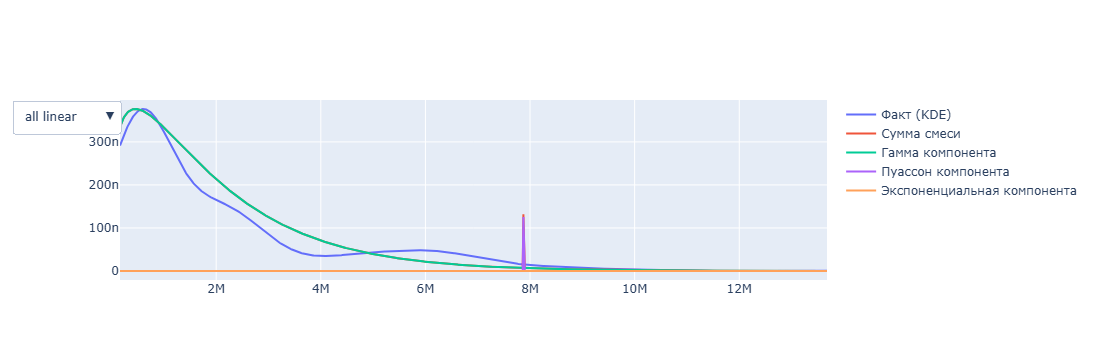

In [ ]:
# Визуализация смеси
if target_for_fitting and 'mixture_params' in locals() and 'target_data' in locals():    
    kde = gaussian_kde(target_data)    
    xx = np.linspace(min(target_data), max(target_data), len(target_data))    
    points = np.arange(0, target_data.max(), 1)    
    fact = kde(xx)    
    poisson_smooth = gaussian_kde(points, weights=poisson.pmf(points, mu=mu))        # Каждая компонента умножается на свой вес    
    gamma_part = gamma.pdf(xx, a, scale=scale) * w_gamma    
    poisson_part = poisson_smooth(xx) * w_poisson    
    expon_part = expon.pdf(xx, scale=1/lambda_) * w_exp    
    sum_3 = gamma_part + poisson_part + expon_part        
    graphs = [fact, sum_3, gamma_part, poisson_part, expon_part]    
    labels = ['Факт (KDE)', 'Сумма смеси', 'Гамма компонента', 'Пуассон компонента', 'Экспоненциальная компонента']        # По умолчанию один субплот (n_subplots=1)    
    # Для сравнения с разными осями можно использовать 
    n_subplots=2   
    plot_multiple(x=xx, y=graphs, labels=labels, n_subplots=1)

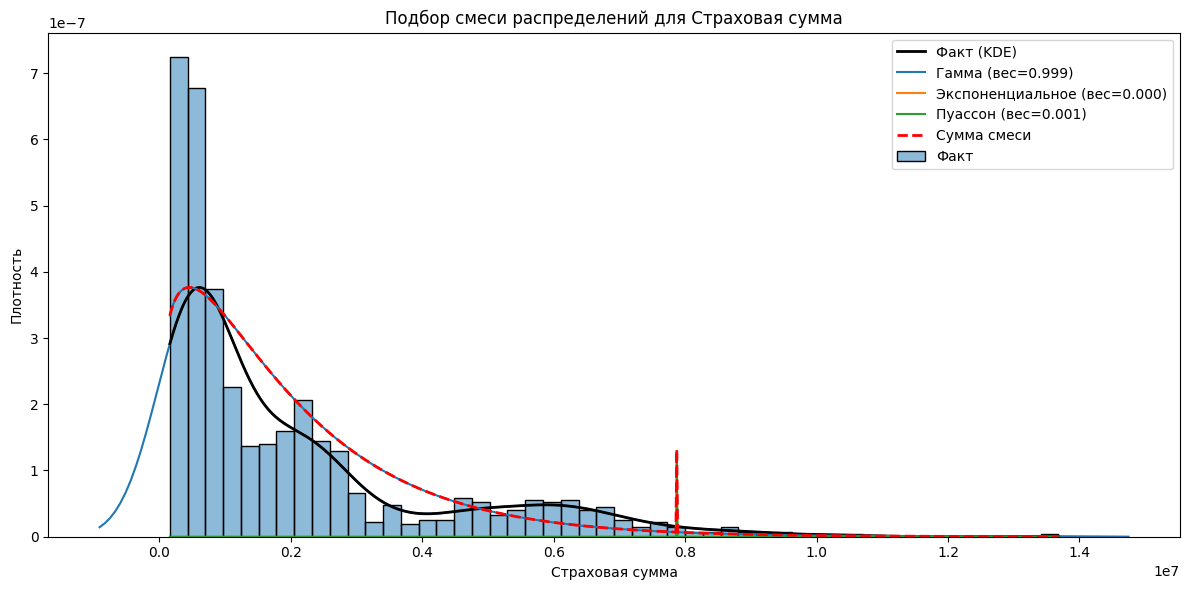

In [ ]:
# Детальная визуализация на гистограмме
if target_for_fitting and 'mixture_params' in locals() and 'target_data' in locals():    
    _, ax = plt.subplots(figsize=(12, 6))    
    sns.histplot(target_data, kde=True, kde_kws=dict(cut=2), 
                 ax=ax, stat='density', label='Факт', bins=50)    
    xx = np.linspace(min(target_data), max(target_data), len(target_data))    
    sns.lineplot(x=xx, y=kde(xx), label='Факт (KDE)', ax=ax, color='black', linewidth=2)        # Каждая компонента умножается на свой вес, чтобы не было горбов от компонент с нулевым весом    
    sns.lineplot(x=xx, y=gamma.pdf(xx, a, scale=scale) * w_gamma, label=f'Гамма (вес={w_gamma:.3f})', ax=ax)    
    sns.lineplot(x=xx, y=expon.pdf(xx, scale=1/lambda_) * w_exp, label=f'Экспоненциальное (вес={w_exp:.3f})', ax=ax)    
    poisson_smooth = gaussian_kde(points, weights=poisson.pmf(points, mu=mu))    
    sns.lineplot(x=xx, y=poisson_smooth(xx) * w_poisson, label=f'Пуассон (вес={w_poisson:.3f})', ax=ax)        # Сумма смеси    
    sum_3 = (gamma.pdf(xx, a, scale=scale) * w_gamma +              expon.pdf(xx, scale=1/lambda_) * w_exp +              poisson_smooth(xx) * w_poisson)    
    sns.lineplot(x=xx, y=sum_3, label='Сумма смеси', ax=ax, color='red', linewidth=2, linestyle='--')    
    ax.set_title(f"Подбор смеси распределений для {target_for_fitting}")    
    ax.set_xlabel(target_for_fitting)    
    ax.set_ylabel('Плотность')    
    ax.legend()    
    plt.tight_layout()    
    plt.show()

## 9. Корреляционный анализ с проверкой численной устойчивости

**Цель:** Изучить связи между признаками и таргетами различными методами, проверить численную устойчивость.

**Что смотрим:** 
- Корреляции между признаками (Pearson, Spearman, Kendall)
- Взаимную информацию (MI)
- Статистические тесты (chi2 для категориальных, ANOVA для числовых vs категориальных)
- Численную устойчивость матриц (condition number, вырожденность, влияние выбросов)

**Зачем:** Понимание зависимостей помогает выбрать признаки для модели и выявить мультиколлинеарность.

In [ ]:
# Вычисление корреляционных матриц различными методами
# Исключаем 'mic', так как он не полностью реализован
correlation_methods = ['pearson', 'spearman', 'kendall', 'mi', 'chi2', 'anova']

print("📊 Вычисление корреляционных матриц...")
print(f"Методы: {', '.join(correlation_methods)}")
print(f"Данные: {df_to_draw.shape[0]} строк, {df_to_draw.shape[1]} колонок\n")

# Вычисляем корреляционные матрицы
correlation_results = compute_correlation_matrices(df_to_draw, methods=correlation_methods)

print(f"\n✅ Вычислено корреляционных матриц: {len(correlation_results)}")
for method in correlation_results:
    print(f"  - {method}: {correlation_results[method].shape}")

📊 Вычисление корреляционных матриц...
Методы: pearson, spearman, kendall, mi, chi2, anova
Данные: 1000 строк, 4 колонок



📊 Анализ типов переменных:
   Числовые: 3 колонок
   Категориальные: 1 колонок
   Потенциально категориальные числовые: 0 колонок
⚠️ Для chi2 нужно минимум 2 категориальные переменные. Пропускаем.

✅ Вычислено корреляционных матриц: 5
  - pearson: (3, 3)
  - spearman: (3, 3)
  - kendall: (3, 3)
  - mi: (4, 4)
  - anova: (4, 4)


📊 Визуализация корреляционных матриц...


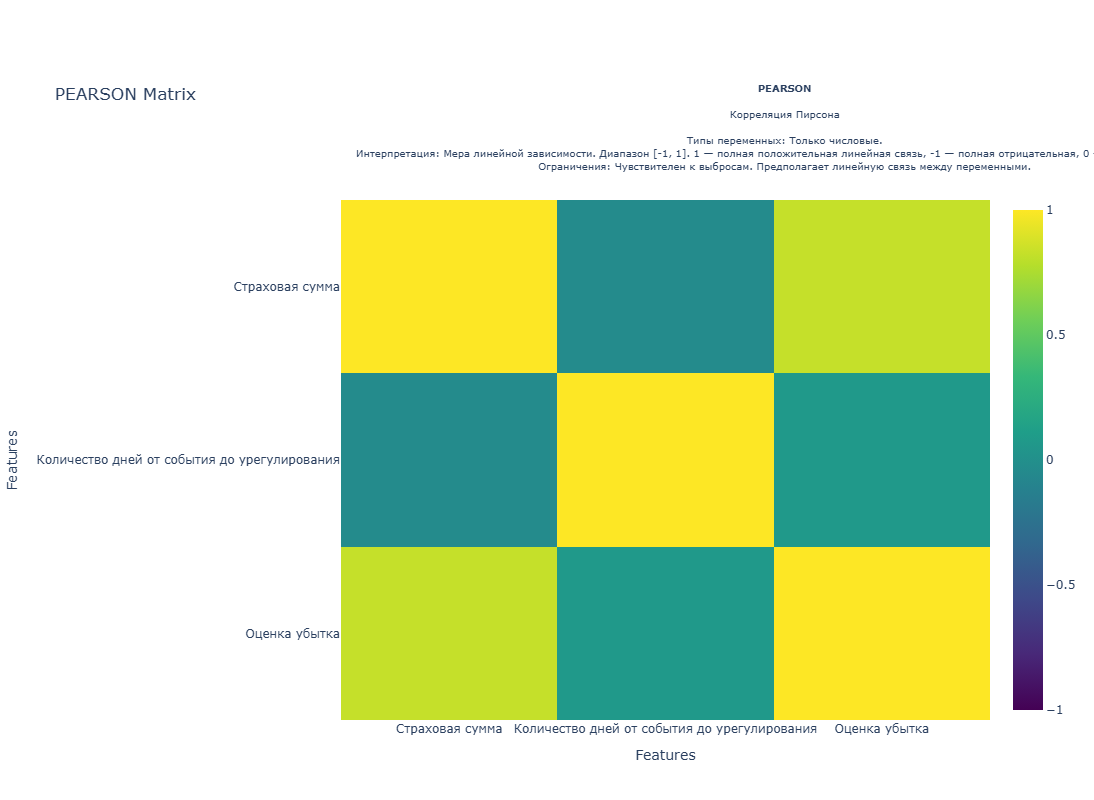

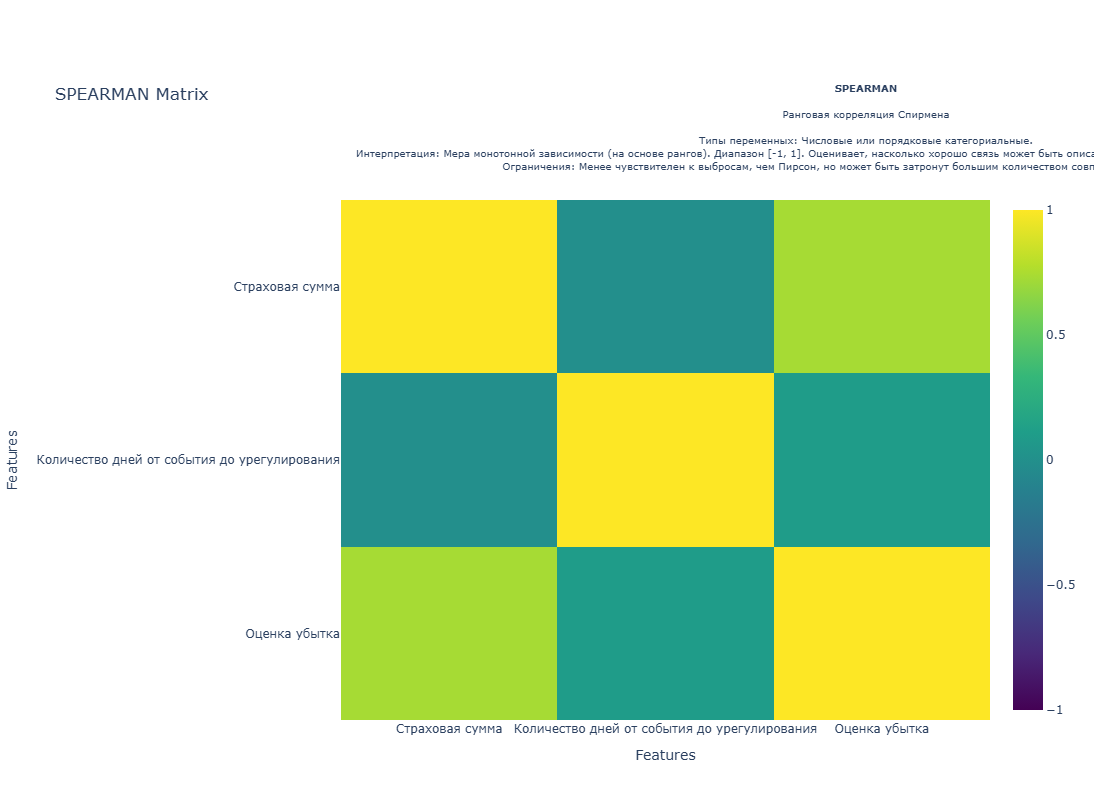

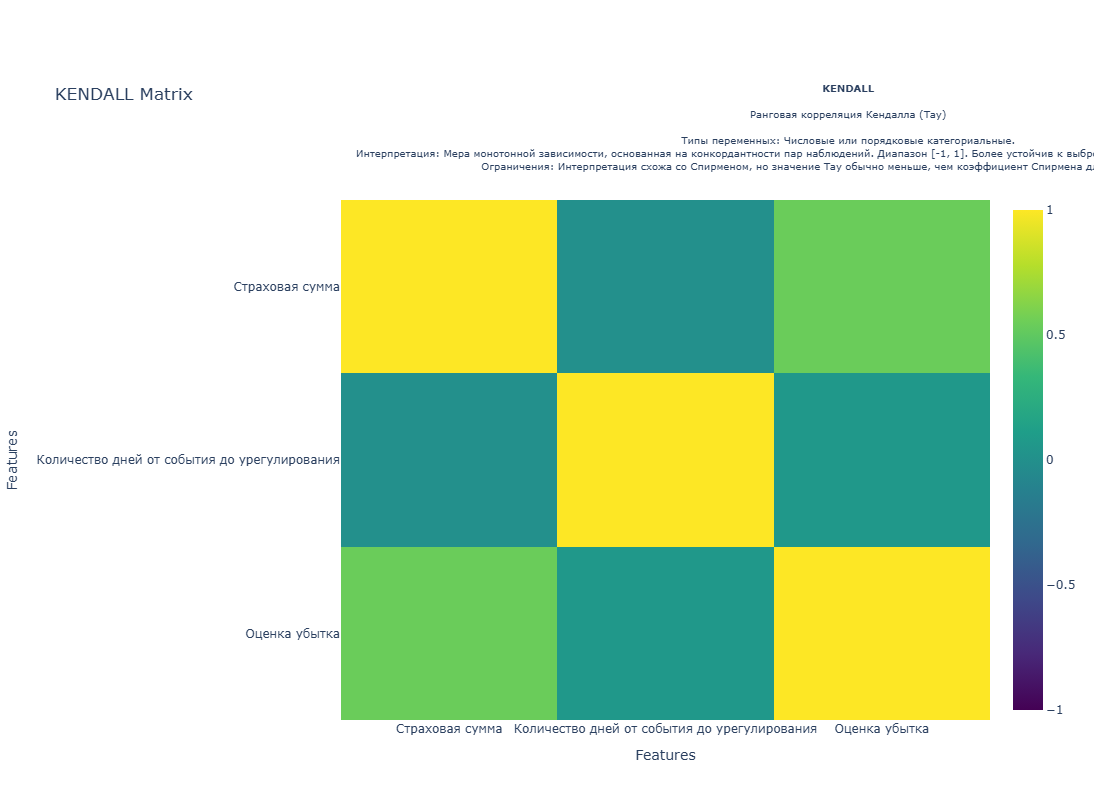

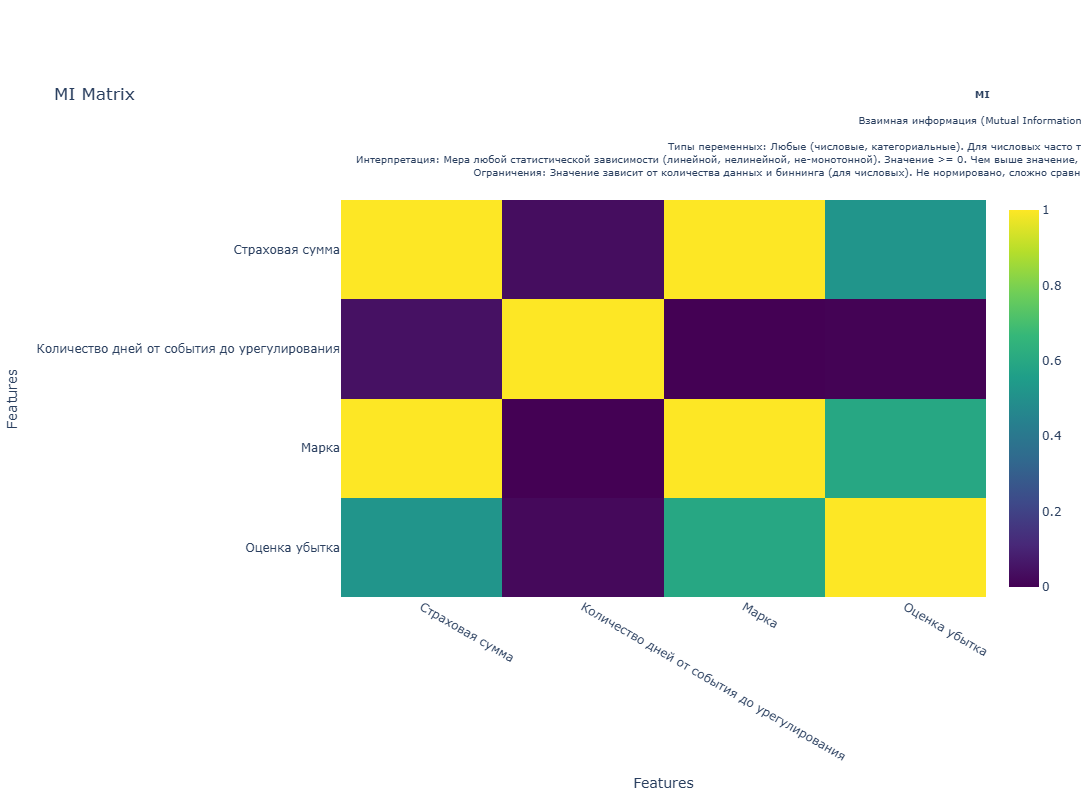

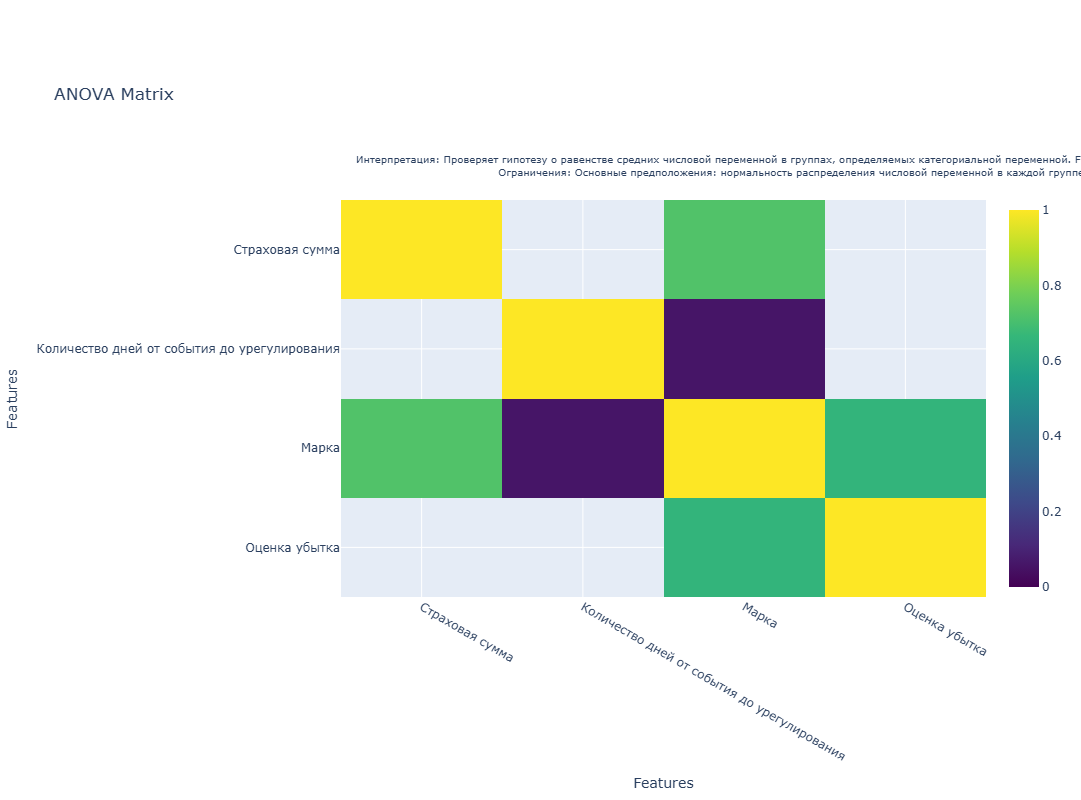

In [ ]:
# Визуализация корреляционных матриц
if correlation_results:
    print("📊 Визуализация корреляционных матриц...")
    plot_correlation_matrices(correlation_results)
else:
    print("⚠️ Нет результатов корреляционного анализа для визуализации")

In [ ]:
# Проверка численной устойчивости корреляционных матриц
# Проверяем condition number, rank, determinant, eigenvalues для числовых корреляций
from numpy.linalg import cond, matrix_rank, det, eigvals

print("🔍 Проверка численной устойчивости корреляционных матриц\n")

# Методы, для которых проверяем численную устойчивость (только числовые корреляции)
numeric_correlation_methods = ['pearson', 'spearman', 'kendall']

for method in numeric_correlation_methods:
    if method not in correlation_results:
        continue
    
    matrix = correlation_results[method]
    
    # Удаляем NaN значения для вычислений
    matrix_clean = matrix.dropna(axis=0, how='all').dropna(axis=1, how='all')
    
    if matrix_clean.empty or matrix_clean.shape[0] < 2:
        print(f"⚠️ {method.upper()}: недостаточно данных для анализа")
        continue
    
    # Преобразуем в numpy array
    matrix_array = matrix_clean.values
    
    print(f"\n{method.upper()} корреляция:")
    print(f"  Размер матрицы: {matrix_array.shape}")
    
    # 1. Condition number (число обусловленности)
    try:
        cond_num = cond(matrix_array)
        print(f"  Condition number: {cond_num:.2e}")
        if cond_num > 1e12:
            print("    ⚠️ ВНИМАНИЕ: Очень высокое число обусловленности - матрица близка к вырожденной!")
        elif cond_num > 1e6:
            print("    ⚠️ ПРЕДУПРЕЖДЕНИЕ: Высокое число обусловленности - возможны проблемы с численной устойчивостью")
        else:
            print("    ✓ Число обусловленности в норме")
    except Exception as e:
        print(f"    ⚠️ Не удалось вычислить condition number: {e}")
    
    # 2. Matrix rank (ранг матрицы)
    try:
        rank = matrix_rank(matrix_array)
        full_rank = min(matrix_array.shape)
        print(f"  Ранг матрицы: {rank} из {full_rank}")
        if rank < full_rank:
            print(f"    ⚠️ ВНИМАНИЕ: Матрица вырождена! Ранг меньше полного на {full_rank - rank}")
        else:
            print("    ✓ Матрица имеет полный ранг")
    except Exception as e:
        print(f"    ⚠️ Не удалось вычислить ранг: {e}")
    
    # 3. Determinant (определитель)
    try:
        determinant = det(matrix_array)
        print(f"  Определитель: {determinant:.2e}")
        if abs(determinant) < 1e-10:
            print("    ⚠️ ВНИМАНИЕ: Определитель близок к нулю - матрица близка к вырожденной!")
        elif abs(determinant) < 1e-6:
            print("    ⚠️ ПРЕДУПРЕЖДЕНИЕ: Малый определитель - возможны проблемы с численной устойчивостью")
        else:
            print("    ✓ Определитель в норме")
    except Exception as e:
        print(f"    ⚠️ Не удалось вычислить определитель: {e}")
    
    # 4. Eigenvalues (собственные значения)
    try:
        eigenvalues = eigvals(matrix_array)
        min_eigenval = np.min(eigenvalues.real)
        max_eigenval = np.max(eigenvalues.real)
        print(f"  Собственные значения: min={min_eigenval:.2e}, max={max_eigenval:.2e}")
        
        # Проверяем на отрицательные собственные значения (для корреляционной матрицы это проблема)
        negative_eigenvals = eigenvalues.real[eigenvalues.real < 0]
        if len(negative_eigenvals) > 0:
            print(f"    ⚠️ ВНИМАНИЕ: Обнаружено {len(negative_eigenvals)} отрицательных собственных значений!")
            print(f"      Минимальное отрицательное: {np.min(negative_eigenvals):.2e}")
        else:
            print("    ✓ Все собственные значения неотрицательны")
        
        # Проверяем на близкие к нулю собственные значения
        near_zero = eigenvalues.real[np.abs(eigenvalues.real) < 1e-6]
        if len(near_zero) > 0:
            print(f"    ⚠️ ПРЕДУПРЕЖДЕНИЕ: Обнаружено {len(near_zero)} собственных значений близких к нулю")
    except Exception as e:
        print(f"    ⚠️ Не удалось вычислить собственные значения: {e}")

print("\n" + "="*60)
print("💡 Интерпретация:")
print("  - Condition number > 1e12: матрица численно неустойчива")
print("  - Ранг < полного ранга: матрица вырождена, есть линейные зависимости")
print("  - Определитель ≈ 0: матрица близка к вырожденной")
print("  - Отрицательные собственные значения: матрица не является корреляционной")
print("="*60)

🔍 Проверка численной устойчивости корреляционных матриц


PEARSON корреляция:
  Размер матрицы: (3, 3)
  Condition number: 1.11e+01
    ✓ Число обусловленности в норме
  Ранг матрицы: 3 из 3
    ✓ Матрица имеет полный ранг
  Определитель: 3.03e-01
    ✓ Определитель в норме
  Собственные значения: min=1.65e-01, max=1.83e+00
    ✓ Все собственные значения неотрицательны

SPEARMAN корреляция:
  Размер матрицы: (3, 3)
  Condition number: 6.64e+00
    ✓ Число обусловленности в норме
  Ранг матрицы: 3 из 3
    ✓ Матрица имеет полный ранг
  Определитель: 4.55e-01
    ✓ Определитель в норме
  Собственные значения: min=2.62e-01, max=1.74e+00
    ✓ Все собственные значения неотрицательны

KENDALL корреляция:
  Размер матрицы: (3, 3)
  Condition number: 3.39e+00
    ✓ Число обусловленности в норме
  Ранг матрицы: 3 из 3
    ✓ Матрица имеет полный ранг
  Определитель: 7.04e-01
    ✓ Определитель в норме
  Собственные значения: min=4.56e-01, max=1.54e+00
    ✓ Все собственные значения неотрицатель

## 10. Feature importance через дерево решений

**Цель:** Оценить важность признаков для предсказания таргета через дерево решений.

**Что смотрим:** Важность каждого признака, структуру дерева.

**Зачем:** Помогает выбрать наиболее информативные признаки для модели.

In [ ]:
# Параметры дерева
tree_params = dict(
    max_depth=5,
    random_state=42,
    min_samples_leaf=0.05
)

In [ ]:
# Создаем пайплайн с кодированием категориальных переменных
preprocessor_tree = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(), selector(dtype_include=['category', 'object']))
])

tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('model', DecisionTreeRegressor(**tree_params))
])

In [ ]:
# Обучаем дерево на данных из fine_schema
# Используем категориальные и числовые признаки из fine_schema
X_tree = df_to_draw[fine_schema.categorical_columns + fine_schema.numeric_columns]
y_tree = df_to_draw[fine_schema.target_columns[0]] if fine_schema.target_columns else df_to_draw[schema.target_columns[0]]

# Альтернатива: использовать все признаки из полной схемы (раскомментировать при необходимости)
# X_tree = df_to_draw[schema.categorical_columns + schema.numeric_columns]
# y_tree = df_to_draw[schema.target_columns[0]]

tree_pipeline.fit(X_tree, y_tree)
decision_tree = tree_pipeline.named_steps['model']
print("Дерево обучено")

Дерево обучено


In [ ]:
# Извлекаем важность признаков
onehot_encoder = tree_pipeline.named_steps['preprocessor'].named_transformers_['cat']
transformed_cats = onehot_encoder.get_feature_names_out()

fi = pd.DataFrame({
    'feature': transformed_cats,
    'importance': decision_tree.feature_importances_
}).sort_values(by='importance', ascending=False)

print("Топ-10 важных признаков:")
display(fi.head(10))

Топ-10 важных признаков:


,feature,importance
5,Марка_Мерседес-Бенц,0.840054
2,Марка_Жигули,0.094611
4,Марка_Лада Самара,0.042125
0,Марка_Lada,0.023209
1,Марка_Mercedes,0.000000
3,Марка_Киа,0.000000


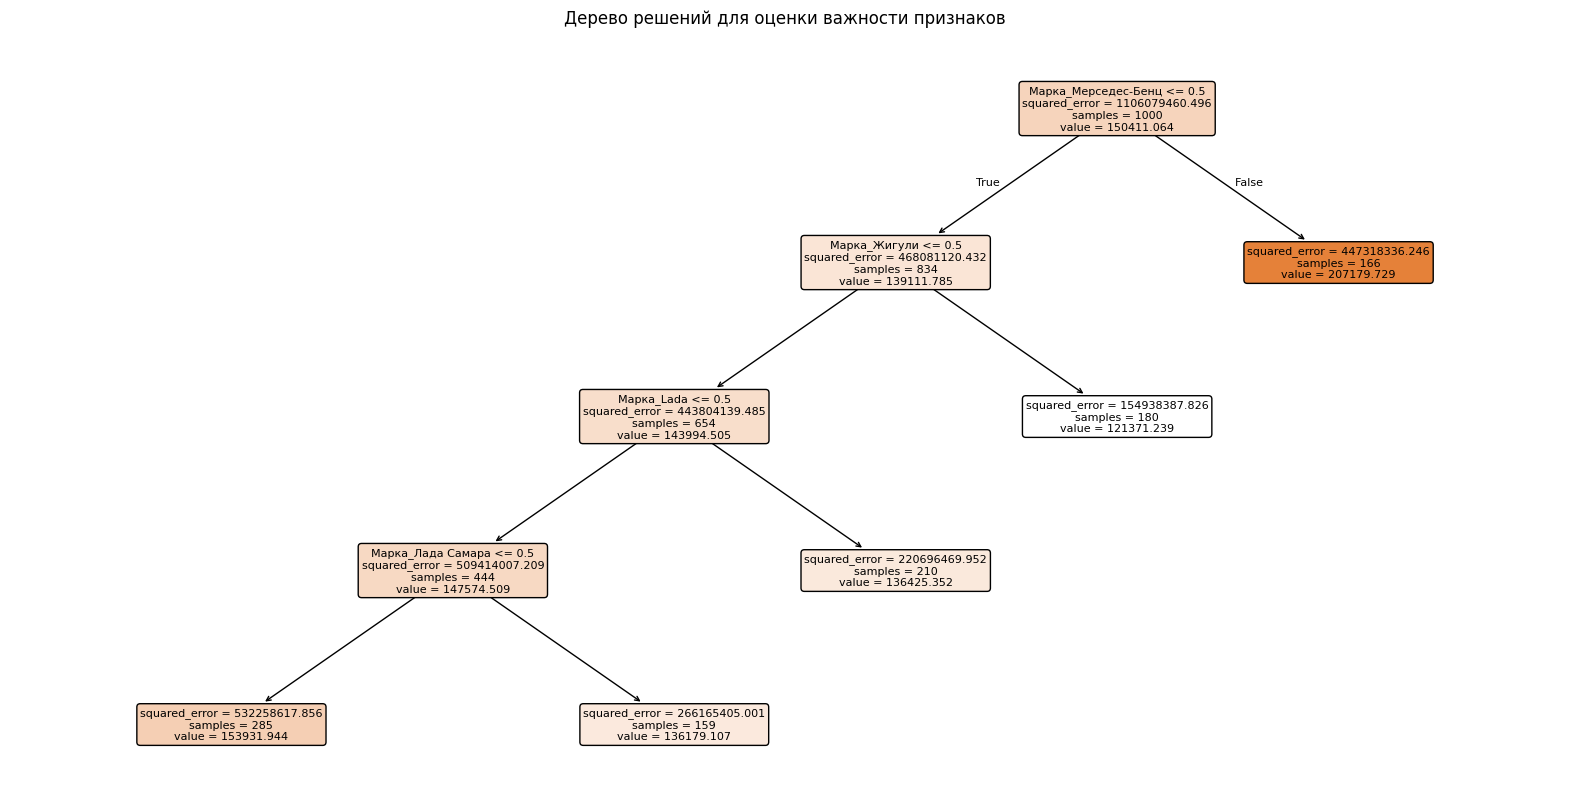

In [ ]:
# Визуализация дерева
plt.figure(figsize=(20, 10))
plot_tree(decision_tree, filled=True, feature_names=transformed_cats, rounded=True, fontsize=8)
plt.title("Дерево решений для оценки важности признаков")
plt.show()

## 11. Многомерные визуализации

**Цель:** Изучить взаимосвязи между несколькими признаками одновременно.

**Что смотрим:** Совместные распределения, взаимодействия признаков, группировки по категориям.

**Зачем:** Помогает выявить паттерны и взаимодействия, которые не видны в одномерном анализе.

In [ ]:
# Выбор переменных для многомерной визуализации
# Изучаем распределение таргета или другой числовой фичи по двум категориальным переменным
# Рекомендация: для второй категориальной переменной выбирать ту, которая имеет небольшое количество уникальных значений

if fine_schema is not None and df_to_draw is not None:
    # Подготовка данных для виджета
    data = {key: {'value': str(value)} for key, value in df_to_draw.head(2).items()}
    
    # Доступные столбцы для выбора
    numeric_and_targets = fine_schema.numeric_columns + fine_schema.target_columns
    categoricals = fine_schema.categorical_columns
    
    # Конфигурация вкладок для MultiTabSelector
    tabs_config_multivariate = [
        {
            'name': 'target_or_numeric',
            'title': 'Target / Numeric',
            'columns': numeric_and_targets,  # Таргет или числовая переменная
            'create_new': False,
            'block_others': False,
            'max_selections': 1  # Только один столбец
        },
        {
            'name': 'categorical_1',
            'title': 'Categorical 1',
            'columns': categoricals,  # Первая категориальная переменная
            'create_new': False,
            'block_others': True,
            'max_selections': 1  # Только один столбец
        },
        {
            'name': 'categorical_2',
            'title': 'Categorical 2',
            'columns': categoricals,  # Вторая категориальная переменная (желательно с небольшим количеством значений)
            'create_new': False,
            'block_others': True,
            'max_selections': 1  # Только один столбец
        }
    ]
    
    multivariate_selector = MultiTabSelector(data, tabs_config_multivariate, show_summary=True)
    display(multivariate_selector)
else:
    print("⚠️ Fine schema не определена или данные не загружены")

MultiTabSelector(children=(Tab(children=(_TabContent(children=(BodyToggleButtonList(children=(CustomToggleButt…

In [ ]:
# Извлекаем выбранные переменные из виджета
if 'multivariate_selector' in locals():
    multivariate_selector._select_all(multivariate_selector._btn_select_all)
    
    target_or_numeric_col = multivariate_selector.target_or_numeric.selected[0] if multivariate_selector.target_or_numeric.selected else None
    categorical_1_col = multivariate_selector.categorical_1.selected[0] if multivariate_selector.categorical_1.selected else None
    categorical_2_col = multivariate_selector.categorical_2.selected[0] if multivariate_selector.categorical_2.selected else None
    
    print(f"Выбраны переменные:")
    print(f"  Target/Numeric: {target_or_numeric_col}")
    print(f"  Categorical 1: {categorical_1_col}")
    print(f"  Categorical 2: {categorical_2_col}")
else:
    # Fallback: используем первые доступные
    target_or_numeric_col = (fine_schema.target_columns[0] if fine_schema.target_columns 
                             else (fine_schema.numeric_columns[0] if fine_schema.numeric_columns else None))
    categorical_1_col = fine_schema.categorical_columns[0] if fine_schema.categorical_columns else None
    categorical_2_col = fine_schema.categorical_columns[1] if len(fine_schema.categorical_columns) > 1 else None
    print("⚠️ Виджет не найден, используем первые доступные переменные")

Выбраны переменные:
  Target/Numeric: None
  Categorical 1: None
  Categorical 2: None


In [ ]:
# Barplot с группировкой
# Показываем зависимость таргета/числовой переменной от первой категориальной, сгруппированную по второй категориальной
if target_or_numeric_col and categorical_1_col and categorical_2_col:
    if all(col in df_to_draw.columns for col in [target_or_numeric_col, categorical_1_col, categorical_2_col]):
        _, ax = plt.subplots(figsize=(20, 5))
        sns.barplot(data=df_to_draw, y=target_or_numeric_col, x=categorical_1_col, hue=categorical_2_col, ax=ax)
        plt.xticks(rotation=70)
        plt.title(f"Зависимость {target_or_numeric_col} от {categorical_1_col} по группам {categorical_2_col}")
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ Не все выбранные столбцы присутствуют в данных")
else:
    print("⚠️ Не выбраны все необходимые переменные (таргет/числовая и две категориальные)")

NameError: name 'target_or_numeric_col' is not defined

In [ ]:
# Violinplot
# Показываем распределение таргета/числовой переменной по первой категориальной, сгруппированное по второй категориальной
if target_or_numeric_col and categorical_1_col and categorical_2_col:
    if all(col in df_to_draw.columns for col in [target_or_numeric_col, categorical_1_col, categorical_2_col]):
        _, ax = plt.subplots(figsize=(20, 5))
        sns.violinplot(data=df_to_draw, y=target_or_numeric_col, x=categorical_1_col, hue=categorical_2_col, ax=ax)
        plt.xticks(rotation=70)
        plt.title(f"Распределение {target_or_numeric_col} по {categorical_1_col} и {categorical_2_col}")
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ Не все выбранные столбцы присутствуют в данных")
else:
    print("⚠️ Не выбраны все необходимые переменные (таргет/числовая и две категориальные)")

⚠️ Не выбраны все необходимые переменные (таргет/числовая и две категориальные)
